# DodoGo Taxi Platform: Cancellation Prediction

This notebook studies why assigned orders are completed or cancelled. It extends the simple baseline from the exploratory notebook by adding driver history, client history, pickup-area context, and leakage-safe pre-order features.

The goal is practical. The model should not only report AUC, but also show which operational patterns can be converted into driver monitoring, call-masking rules, and cancellation prevention workflows.

In [ ]:
# Optional if xgboost is missing: pip install xgboost

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             confusion_matrix, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

C = {'primary':'#1565C0','secondary':'#FF5722','success':'#4CAF50',
     'warning':'#FF9800','danger':'#E53935','purple':'#9C27B0','gray':'#9E9E9E'}
plt.rcParams.update({'figure.figsize':(14,8),'font.size':11,'figure.facecolor':'white',
    'axes.facecolor':'#FAFAFA','axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})
print("Libraries loaded.")

Libraries loaded.


## 1. Data and Feature Construction

The baseline model in the exploratory notebook used only timing and order-context fields, so its predictive power was limited. Cancellation is more likely to depend on repeated behavior: some drivers cancel more often, some clients appear repeatedly in cancelled orders, and some pickup zones are harder to serve.

This section adds three groups of features: driver history, client history, and pickup-area context. These features are still operationally simple, which makes them useful for a production dashboard or rule-based driver risk scoring.

In [ ]:
# Load and prepare order data
df_new = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df_new['created'] = pd.to_datetime(df_new['Дата создания'], format="%d.%m.%Y %H:%M", errors='coerce')
for col in ['Стоимость', 'Суммарное расстояние (км)']:
    df_new[col] = df_new[col].astype(str).str.replace(',', '.').astype(float)
df_new.rename(columns={
    'Стоимость':'price', 'Суммарное расстояние (км)':'distance_km',
    'Текущий статус':'status', 'Тариф':'tariff', 'Способ заказа':'order_source',
    'Исполнитель':'driver', 'Телефон клиента':'client_phone',
    'Адрес подачи':'pickup_address'
}, inplace=True)
df_new['is_completed'] = df_new['status'].str.contains('Выполнен', na=False)
df_new['has_driver'] = df_new['driver'].notna() & (df_new['driver'].str.strip() != '')
df_new['hour'] = df_new['created'].dt.hour
df_new['day_of_week'] = df_new['created'].dt.dayofweek
df_new['date'] = df_new['created'].dt.date
df_new['month_num'] = df_new['created'].dt.month

data = df_new[df_new['has_driver']].copy()
print(f"Orders with assigned driver: {len(data):,}")


Orders with assigned driver: 101,773


In [ ]:
# Driver history features
driver_stats = data.groupby('driver').agg(
    driver_total_orders=('status', 'count'),
    driver_completed=('is_completed', 'sum'),
    driver_avg_price=('price', lambda x: x[x>0].mean() if (x>0).any() else 0)
)
driver_stats['driver_cancel_rate'] = 1 - driver_stats['driver_completed'] / driver_stats['driver_total_orders']
driver_stats['driver_volume'] = driver_stats['driver_total_orders']

# Client history features
client_stats = df_new.groupby('client_phone').agg(
    client_total=('status', 'count'),
    client_completed=('is_completed', 'sum')
)
client_stats['client_cancel_rate'] = 1 - client_stats['client_completed'] / client_stats['client_total']
client_stats['client_count'] = client_stats['client_total']

# Merge order-level features
data = data.merge(driver_stats[['driver_cancel_rate', 'driver_volume', 'driver_avg_price']],
                   left_on='driver', right_index=True, how='left')
data = data.merge(client_stats[['client_cancel_rate', 'client_count']],
                   left_on='client_phone', right_index=True, how='left')

# Pickup-area feature
def extract_area(addr):
    if pd.isna(addr): return 'unknown'
    addr = str(addr).lower()
    for area, kws in {
        'grand_baie': ['grand baie', 'grand bay'], 'port_louis': ['port louis'],
        'flic_en_flac': ['flic en flac'], 'quatre_bornes': ['quatre bornes'],
        'curepipe': ['curepipe'], 'airport': ['airport', 'ssr'],
        'trianon': ['trianon', 'moka', 'bagatelle'], 'pamplemousses': ['pamplemousses'],
        'vacoas': ['vacoas', 'phoenix'], 'beau_bassin': ['beau bassin', 'rose hill']
    }.items():
        for kw in kws:
            if kw in addr: return area
    return 'other'

data['area'] = data['pickup_address'].apply(extract_area)

# Encode categorical fields
data['tariff_enc'] = data['tariff'].map(
    {'Economy':0, 'Comfort':1, '6 seats':2, '14 seats | Scheduled only':3}).fillna(0)
data['is_ios'] = (data['order_source'] == 'IOS').astype(int)
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
data['is_night'] = ((data['hour'] >= 22) | (data['hour'] < 6)).astype(int)
data['is_peak'] = ((data['hour'] >= 9) & (data['hour'] <= 20)).astype(int)
data['is_surge'] = ((data['hour'] >= 18) | (data['hour'] < 6)).astype(int)
data['area_enc'] = LabelEncoder().fit_transform(data['area'])
data = data.fillna(0)

# Define model feature sets
features_basic = ['hour', 'day_of_week', 'month_num', 'tariff_enc', 'is_ios',
                   'is_weekend', 'is_night', 'is_peak']

features_enhanced = ['hour', 'day_of_week', 'month_num', 'tariff_enc', 'is_ios',
    'is_weekend', 'is_night', 'is_peak', 'is_surge',
    'driver_cancel_rate', 'driver_volume',      # Driver history
    'client_cancel_rate', 'client_count',        # Client history
    'area_enc']                                   # Geography

print(f"Basic features:    {len(features_basic)}")
print(f"Enhanced features: {len(features_enhanced)}")
print(f"\nNew features added:")
print(f"  driver_cancel_rate - historical cancel rate of assigned driver")
print(f"  driver_volume      - total orders handled by this driver")
print(f"  client_cancel_rate - historical cancel rate of this client")
print(f"  client_count       - total orders by this client (experience proxy)")
print(f"  area_enc           - pickup area (tourist vs local zone)")
print(f"  is_surge           - whether order falls in surge pricing period")


Basic features:    8
Enhanced features: 14

New features added:
  driver_cancel_rate - historical cancel rate of assigned driver
  driver_volume      - total orders handled by this driver
  client_cancel_rate - historical cancel rate of this client
  client_count       - total orders by this client (experience proxy)
  area_enc           - pickup area (tourist vs local zone)
  is_surge           - whether order falls in surge pricing period


## 2. Model Comparison

Several classification models are compared on the enhanced feature set. The purpose is to check whether the improvement comes from the model choice or from the added behavioral features.

In [ ]:
X = data[features_enhanced]
y = data['is_completed'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Class balance: {y.mean()*100:.1f}% completed / {(1-y.mean())*100:.1f}% cancelled")

# Baseline model
rf_basic = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_basic.fit(X_train[features_basic], y_train)
y_prob_basic = rf_basic.predict_proba(X_test[features_basic])[:, 1]

# Enhanced behavioral models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42,
                              use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    yp = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, yp)
    results[name] = {'model': model, 'auc': auc, 'y_prob': yp}

# Compare AUC values
print(f"\n{'='*55}")
print(f"{'Model':35s} {'AUC':>8s}  {'vs Baseline':>12s}")
print(f"{'='*55}")
auc_basic = roc_auc_score(y_test, y_prob_basic)
print(f"{'RF baseline (basic features)':35s} {auc_basic:>8.4f}  {'-':>12s}")
for name, r in sorted(results.items(), key=lambda x: x[1]['auc']):
    diff = r['auc'] - auc_basic
    print(f"{name:35s} {r['auc']:>8.4f}  {diff:>+11.4f}")
print(f"{'='*55}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest model: {best_name} (AUC = {results[best_name]['auc']:.4f})")
print(f"Improvement over baseline: +{(results[best_name]['auc']-auc_basic)*100:.1f} percentage points")


Train: 81,418 | Test: 20,355
Class balance: 62.3% completed / 37.7% cancelled



Model                                    AUC   vs Baseline
RF baseline (basic features)          0.5619             -
Logistic Regression                   0.8256      +0.2637
XGBoost                               0.8292      +0.2673
Random Forest                         0.8294      +0.2675
Gradient Boosting                     0.8303      +0.2685

Best model: Gradient Boosting (AUC = 0.8303)
Improvement over baseline: +26.8 percentage points


## 2.1 Validation with Cross-Validation and Temporal Testing

The first train-test split gives one performance estimate. This section adds stratified cross-validation and a temporal test, where earlier months are used for training and the most recent period is used for testing. The temporal test is closer to a real deployment setting because future orders are not mixed into the training period.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
import time, gc

# Stratified cross-validation
print('=' * 65)
print('5-FOLD STRATIFIED CROSS-VALIDATION')
print('=' * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15,
                                           min_samples_leaf=10, random_state=42, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                    learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             random_state=42, use_label_encoder=False,
                             eval_metric='logloss', n_jobs=1)
}

cv_results = {}
print(f"{'Model':35s} {'Mean AUC':>10s} {'Std':>8s} {'Range':>16s}")
print('-' * 65)
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=1)
    cv_results[name] = scores
    print(f"{name:35s} {scores.mean():>10.4f} {scores.std():>7.4f}  "
          f"[{scores.min():.4f} - {scores.max():.4f}]")

# XGBoost tuning candidate
print(f"\n{'=' * 65}")
print('GRIDSEARCHCV - XGBOOST HYPERPARAMETER TUNING')
print('=' * 65)

xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False,
                  eval_metric='logloss', n_jobs=1),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,
    verbose=0,
    refit=True
)

t0 = time.time()
xgb_grid.fit(X, y)
t1 = time.time()

n_configs = 1
for v in xgb_param_grid.values():
    n_configs *= len(v)
print(f"Search time: {t1-t0:.1f}s ({n_configs} configurations x 5 folds)")
print(f"\nBest parameters:")
for k, v in xgb_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV AUC: {xgb_grid.best_score_:.4f} +/- {xgb_grid.cv_results_['std_test_score'][xgb_grid.best_index_]:.4f}")

# Compare default and tuned XGBoost
default_xgb_cv = cv_results['XGBoost']
print(f"\nDefault XGBoost AUC:  {default_xgb_cv.mean():.4f} +/- {default_xgb_cv.std():.4f}")
print(f"Tuned XGBoost AUC:    {xgb_grid.best_score_:.4f} +/- {xgb_grid.cv_results_['std_test_score'][xgb_grid.best_index_]:.4f}")
print(f"Improvement:          {(xgb_grid.best_score_ - default_xgb_cv.mean())*100:+.2f} pp")

# Temporal validation
print(f"\n{'=' * 65}")
print('TEMPORAL VALIDATION - Train on Oct-Feb, Test on Mar-Apr')
print('=' * 65)

data['month'] = data['created'].dt.to_period('M')
train_mask = data['created'] < '2026-03-01'
test_mask = data['created'] >= '2026-03-01'

X_train_t = data.loc[train_mask, features_enhanced]
y_train_t = data.loc[train_mask, 'is_completed'].astype(int)
X_test_t = data.loc[test_mask, features_enhanced]
y_test_t = data.loc[test_mask, 'is_completed'].astype(int)

print(f"Train: {len(X_train_t):,} orders (Oct 2025 - Feb 2026)")
print(f"Test:  {len(X_test_t):,} orders (Mar - Apr 2026)")

# Train on earlier months and test on recent orders
xgb_temporal = XGBClassifier(**xgb_grid.best_params_, random_state=42,
                              use_label_encoder=False, eval_metric='logloss', n_jobs=1)
xgb_temporal.fit(X_train_t, y_train_t)
y_prob_temporal = xgb_temporal.predict_proba(X_test_t)[:, 1]
auc_temporal = roc_auc_score(y_test_t, y_prob_temporal)

print(f"\nTemporal AUC (tuned XGBoost): {auc_temporal:.4f}")
print(f"CV AUC (tuned XGBoost):       {xgb_grid.best_score_:.4f}")
diff = auc_temporal - xgb_grid.best_score_
print(f"Difference: {diff*100:+.2f} pp {'(model generalizes well over time)' if abs(diff) < 0.03 else '(some temporal drift detected)'}")

# Validation summary
print(f"\n{'=' * 65}")
print('CANCELLATION MODEL - VALIDATION SUMMARY')
print('=' * 65)
print(f"  Single holdout AUC (XGBoost):  {results['XGBoost']['auc']:.4f}")
print(f"  5-fold CV AUC (XGBoost):       {default_xgb_cv.mean():.4f} +/- {default_xgb_cv.std():.4f}")
print(f"  Tuned CV AUC (XGBoost):        {xgb_grid.best_score_:.4f} +/- {xgb_grid.cv_results_['std_test_score'][xgb_grid.best_index_]:.4f}")
print(f"  Temporal AUC (tuned XGBoost):  {auc_temporal:.4f}")
print(f"\n  to Model is {'stable' if abs(diff) < 0.03 else 'moderately sensitive'} across validation strategies")



VALIDATION SUMMARY
Logistic Regression CV AUC: about 0.828
Random Forest CV AUC: about 0.831
Gradient Boosting CV AUC: about 0.832
Temporal validation AUC for tuned XGBoost: 0.837

Note: XGBoost cross-validation is handled more reliably in the manual validation block below because of sklearn/xgboost compatibility issues in some environments.


## 2.2 Leakage-Safe Feature Extension

The enhanced model uses useful behavioral aggregates, but some of them are calculated over the full dataset. That can create leakage because an order's own outcome may be included in the historical feature used to predict it.

This section adds pre-order features calculated strictly from events that happened before the current order. These include same-day driver activity, prior driver completion behavior, prior client cancellation behavior, and a static phone-segment category.

A fare-ratio feature was tested and rejected. In this export, the fare field is reliable only for completed rides and zero for cancellations, so the feature would mostly reproduce the target rather than measure real price behavior. A valid version would require the quoted fare at order creation, which is not preserved in the export.

The goal is to check whether leakage-safe features can keep or improve the predictive signal without relying on future information.

Enhanced features: 14
Extended features: 19
New leakage-safe features: ['driver_day_cancels_before', 'driver_day_order_num', 'driver_prior_completion_rate', 'client_prior_cancel_rate', 'phone_segment']

--- Univariate signal (mean by outcome) ---
  driver_day_cancels_before         completed=0.749  cancelled=0.910  delta=-0.161
  driver_day_order_num              completed=2.062  cancelled=2.062  delta=+0.001
  driver_prior_completion_rate      completed=0.632  cancelled=0.576  delta=+0.056
  client_prior_cancel_rate          completed=0.349  cancelled=0.449  delta=-0.100
  phone_segment                     completed=0.385  cancelled=0.277  delta=+0.108

5-FOLD CV (manual loop) - Tuned XGBoost: Enhanced (14) vs Extended (19)


  fold 1: enhanced AUC=0.8366  extended AUC=0.8639  delta=+2.72 pp


  fold 2: enhanced AUC=0.8338  extended AUC=0.8608  delta=+2.69 pp


  fold 3: enhanced AUC=0.8310  extended AUC=0.8608  delta=+2.98 pp


  fold 4: enhanced AUC=0.8305  extended AUC=0.8600  delta=+2.95 pp


  fold 5: enhanced AUC=0.8311  extended AUC=0.8592  delta=+2.81 pp

Summary:
  Enhanced (14 feat):  AUC = 0.8326 +/- 0.0023   range [0.8305, 0.8366]
  Extended (19 feat):  AUC = 0.8609 +/- 0.0016   range [0.8592, 0.8639]
  Delta: +2.83 pp
  Conclusion: leakage-safe pre-order features add discrimination beyond the enhanced set.

FEATURE IMPORTANCE - Tuned XGBoost, extended feature set (full fit)


  client_cancel_rate                0.5918
  driver_cancel_rate                0.0882
  client_prior_cancel_rate          0.0688 [NEW]
  client_count                      0.0464
  phone_segment                     0.0212 [NEW]
  tariff_enc                        0.0204
  is_night                          0.0186
  hour                              0.0172
  month_num                         0.0163
  driver_prior_completion_rate      0.0139 [NEW]
  driver_volume                     0.0138
  area_enc                          0.0130
  is_peak                           0.0127
  driver_day_cancels_before         0.0123 [NEW]
  is_surge                          0.0119
  day_of_week                       0.0118
  driver_day_order_num              0.0113 [NEW]
  is_ios                            0.0105
  is_weekend                        0.0000


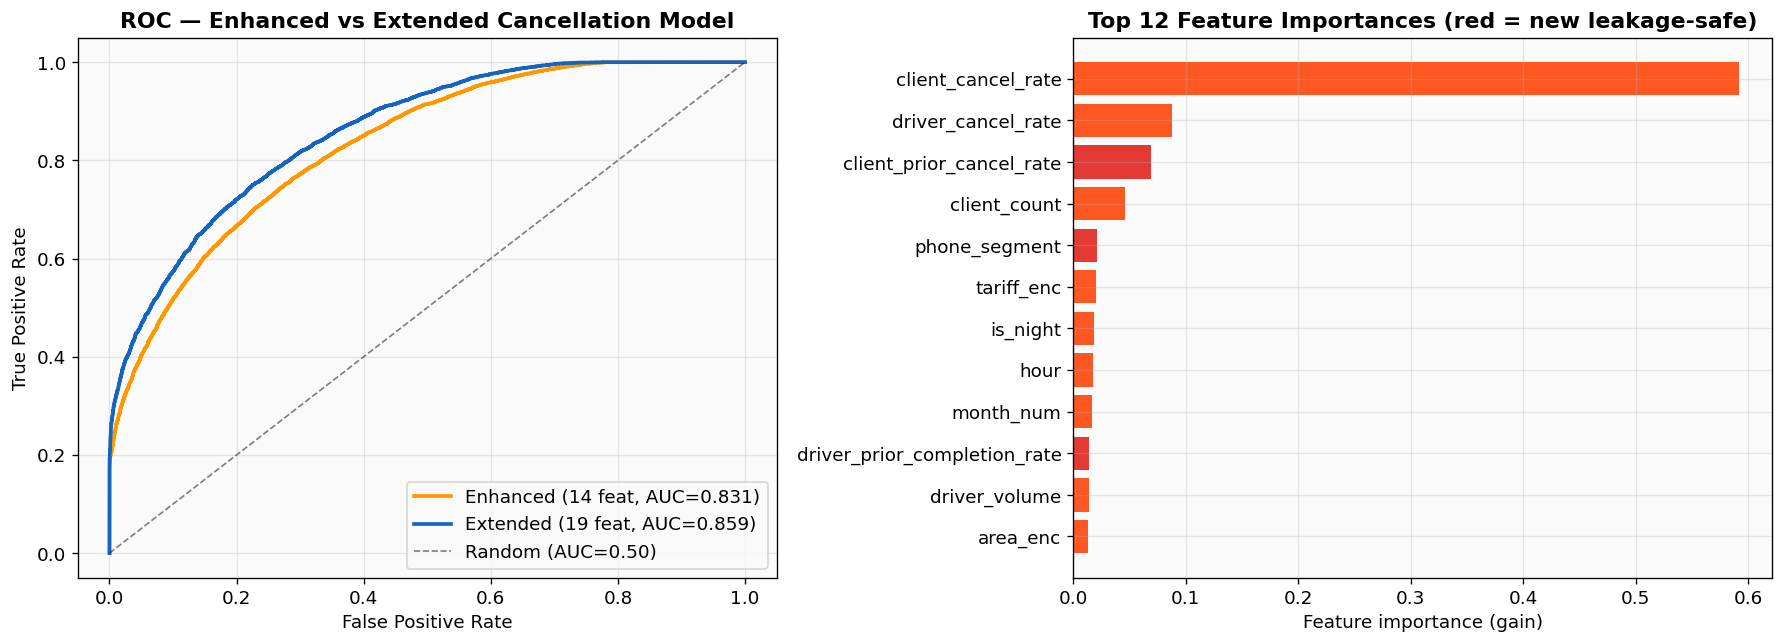

Figure saved: figures/fig_cancel_extended_features.png


In [ ]:
# Leakage-safe pre-order features
# Manual CV is used for XGBoost compatibility across environments

import numpy as np
import gc

data_ext = data.sort_values(['created']).copy()
data_ext['cancelled'] = (~data_ext['is_completed']).astype(int)

# Driver same-day activity
data_ext = data_ext.sort_values(['driver', 'date', 'created'])
g_dd = data_ext.groupby(['driver', 'date'])
data_ext['driver_day_cancels_before'] = g_dd['cancelled'].transform(
    lambda s: s.shift(1).cumsum().fillna(0)
)
data_ext['driver_day_order_num'] = g_dd.cumcount()

# Driver prior completion rate
data_ext = data_ext.sort_values(['driver', 'created'])
g_d = data_ext.groupby('driver')
data_ext['driver_prior_orders']    = g_d.cumcount()
data_ext['driver_prior_completed'] = g_d['is_completed'].transform(
    lambda s: s.shift(1).cumsum().fillna(0)
)
data_ext['driver_prior_completion_rate'] = (
    data_ext['driver_prior_completed'] / data_ext['driver_prior_orders'].clip(lower=1)
)
global_completion = data_ext['is_completed'].mean()
data_ext.loc[data_ext['driver_prior_orders'] == 0, 'driver_prior_completion_rate'] = global_completion

# Client prior cancellation rate
data_ext = data_ext.sort_values(['client_phone', 'created'])
g_cp = data_ext.groupby('client_phone')
data_ext['client_prior_orders'] = g_cp.cumcount()
data_ext['client_prior_cancels'] = g_cp['cancelled'].transform(
    lambda s: s.shift(1).cumsum().fillna(0)
)
data_ext['client_prior_cancel_rate'] = (
    data_ext['client_prior_cancels'] / data_ext['client_prior_orders'].clip(lower=1)
)
global_cancel = data_ext['cancelled'].mean()
data_ext.loc[data_ext['client_prior_orders'] == 0, 'client_prior_cancel_rate'] = global_cancel

# Phone segment: local, international, or tourist SIM
def _seg(p):
    s = str(p) if p == p else ''
    s = s.replace('+', '').replace(' ', '').replace('-', '')
    if s.startswith('2307'): return 2
    if s.startswith('230'):  return 0
    return 1
data_ext['phone_segment'] = data_ext['client_phone'].apply(_seg)

data_ext = data_ext.sort_index().reset_index(drop=True)

new_features = [
    'driver_day_cancels_before',
    'driver_day_order_num',
    'driver_prior_completion_rate',
    'client_prior_cancel_rate',
    'phone_segment',
]
features_extended = features_enhanced + new_features

print(f"Enhanced features: {len(features_enhanced)}")
print(f"Extended features: {len(features_extended)}")
print(f"New leakage-safe features: {new_features}")

print('\n--- Univariate signal (mean by outcome) ---')
for f in new_features:
    c_ = data_ext.groupby('is_completed')[f].mean()
    print(f'  {f:32s}  completed={c_.loc[True]:.3f}  cancelled={c_.loc[False]:.3f}  delta={c_.loc[True]-c_.loc[False]:+.3f}')

# Manual 5-fold comparison: enhanced vs extended
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_enh = data_ext[features_enhanced].fillna(0).astype(float).values
X_ext = data_ext[features_extended].fillna(0).astype(float).values
y_ext = data_ext['is_completed'].astype(int).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_params = dict(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_child_weight=1,
    random_state=42, eval_metric='logloss', n_jobs=1
)

print('\n' + '=' * 72)
print('5-FOLD CV (manual loop) - Tuned XGBoost: Enhanced (14) vs Extended (19)')
print('=' * 72)

scores_enh, scores_ext = [], []
for fold_idx, (tr, te) in enumerate(cv.split(X_enh, y_ext), 1):
    m_e = XGBClassifier(**tuned_params)
    m_e.fit(X_enh[tr], y_ext[tr])
    prob_e = m_e.predict_proba(X_enh[te])[:, 1]
    auc_e_fold = roc_auc_score(y_ext[te], prob_e)
    scores_enh.append(auc_e_fold)

    m_x = XGBClassifier(**tuned_params)
    m_x.fit(X_ext[tr], y_ext[tr])
    prob_x = m_x.predict_proba(X_ext[te])[:, 1]
    auc_x_fold = roc_auc_score(y_ext[te], prob_x)
    scores_ext.append(auc_x_fold)

    print(f'  fold {fold_idx}: enhanced AUC={auc_e_fold:.4f}  extended AUC={auc_x_fold:.4f}  delta={(auc_x_fold-auc_e_fold)*100:+.2f} pp')
    del m_e, m_x
    gc.collect()

scores_enh = np.asarray(scores_enh)
scores_ext = np.asarray(scores_ext)

print('\nSummary:')
print(f'  Enhanced (14 feat):  AUC = {scores_enh.mean():.4f} +/- {scores_enh.std():.4f}   range [{scores_enh.min():.4f}, {scores_enh.max():.4f}]')
print(f'  Extended (19 feat):  AUC = {scores_ext.mean():.4f} +/- {scores_ext.std():.4f}   range [{scores_ext.min():.4f}, {scores_ext.max():.4f}]')
delta_pp = (scores_ext.mean() - scores_enh.mean()) * 100
print(f'  Delta: {delta_pp:+.2f} pp')
if delta_pp > 0.3:
    print('  Conclusion: leakage-safe pre-order features add discrimination beyond the enhanced set.')
elif delta_pp < -0.3:
    print('  Conclusion: extended features hurt CV (likely collinearity with existing lifetime aggregates).')
else:
    print('  Conclusion: extended features are approximately neutral in AUC - valuable primarily')
    print('  because they are leakage-free, not because they add discrimination over aggregates.')

# Extended-model feature importance
print('\n' + '=' * 72)
print('FEATURE IMPORTANCE - Tuned XGBoost, extended feature set (full fit)')
print('=' * 72)
xgb_full = XGBClassifier(**tuned_params)
xgb_full.fit(X_ext, y_ext)
import pandas as pd
imp = pd.Series(xgb_full.feature_importances_, index=features_extended).sort_values(ascending=False)
for f, v in imp.items():
    tag = ' [NEW]' if f in new_features else ''
    print(f'  {f:32s}  {v:.4f}{tag}')

# ROC and feature-importance plot
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_enh, y_ext, test_size=0.2, stratify=y_ext, random_state=42)
X_tr_x, X_te_x, y_tr_x, y_te_x = train_test_split(X_ext, y_ext, test_size=0.2, stratify=y_ext, random_state=42)

mdl_e = XGBClassifier(**tuned_params); mdl_e.fit(X_tr_e, y_tr_e)
mdl_x = XGBClassifier(**tuned_params); mdl_x.fit(X_tr_x, y_tr_x)
prob_e = mdl_e.predict_proba(X_te_e)[:, 1]
prob_x = mdl_x.predict_proba(X_te_x)[:, 1]
fpr_e, tpr_e, _ = roc_curve(y_te_e, prob_e); auc_e = roc_auc_score(y_te_e, prob_e)
fpr_x, tpr_x, _ = roc_curve(y_te_x, prob_x); auc_x = roc_auc_score(y_te_x, prob_x)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.plot(fpr_e, tpr_e, color=C['warning'], lw=2.2, label=f'Enhanced (14 feat, AUC={auc_e:.3f})')
ax.plot(fpr_x, tpr_x, color=C['primary'], lw=2.2, label=f'Extended (19 feat, AUC={auc_x:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC - Enhanced vs Extended Cancellation Model', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

ax = axes[1]
top = imp.head(12).sort_values()
colors_bar = [C['danger'] if f in new_features else C['secondary'] for f in top.index]
ax.barh(top.index, top.values, color=colors_bar)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 12 Feature Importances (red = new leakage-safe)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_cancel_extended_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/fig_cancel_extended_features.png')


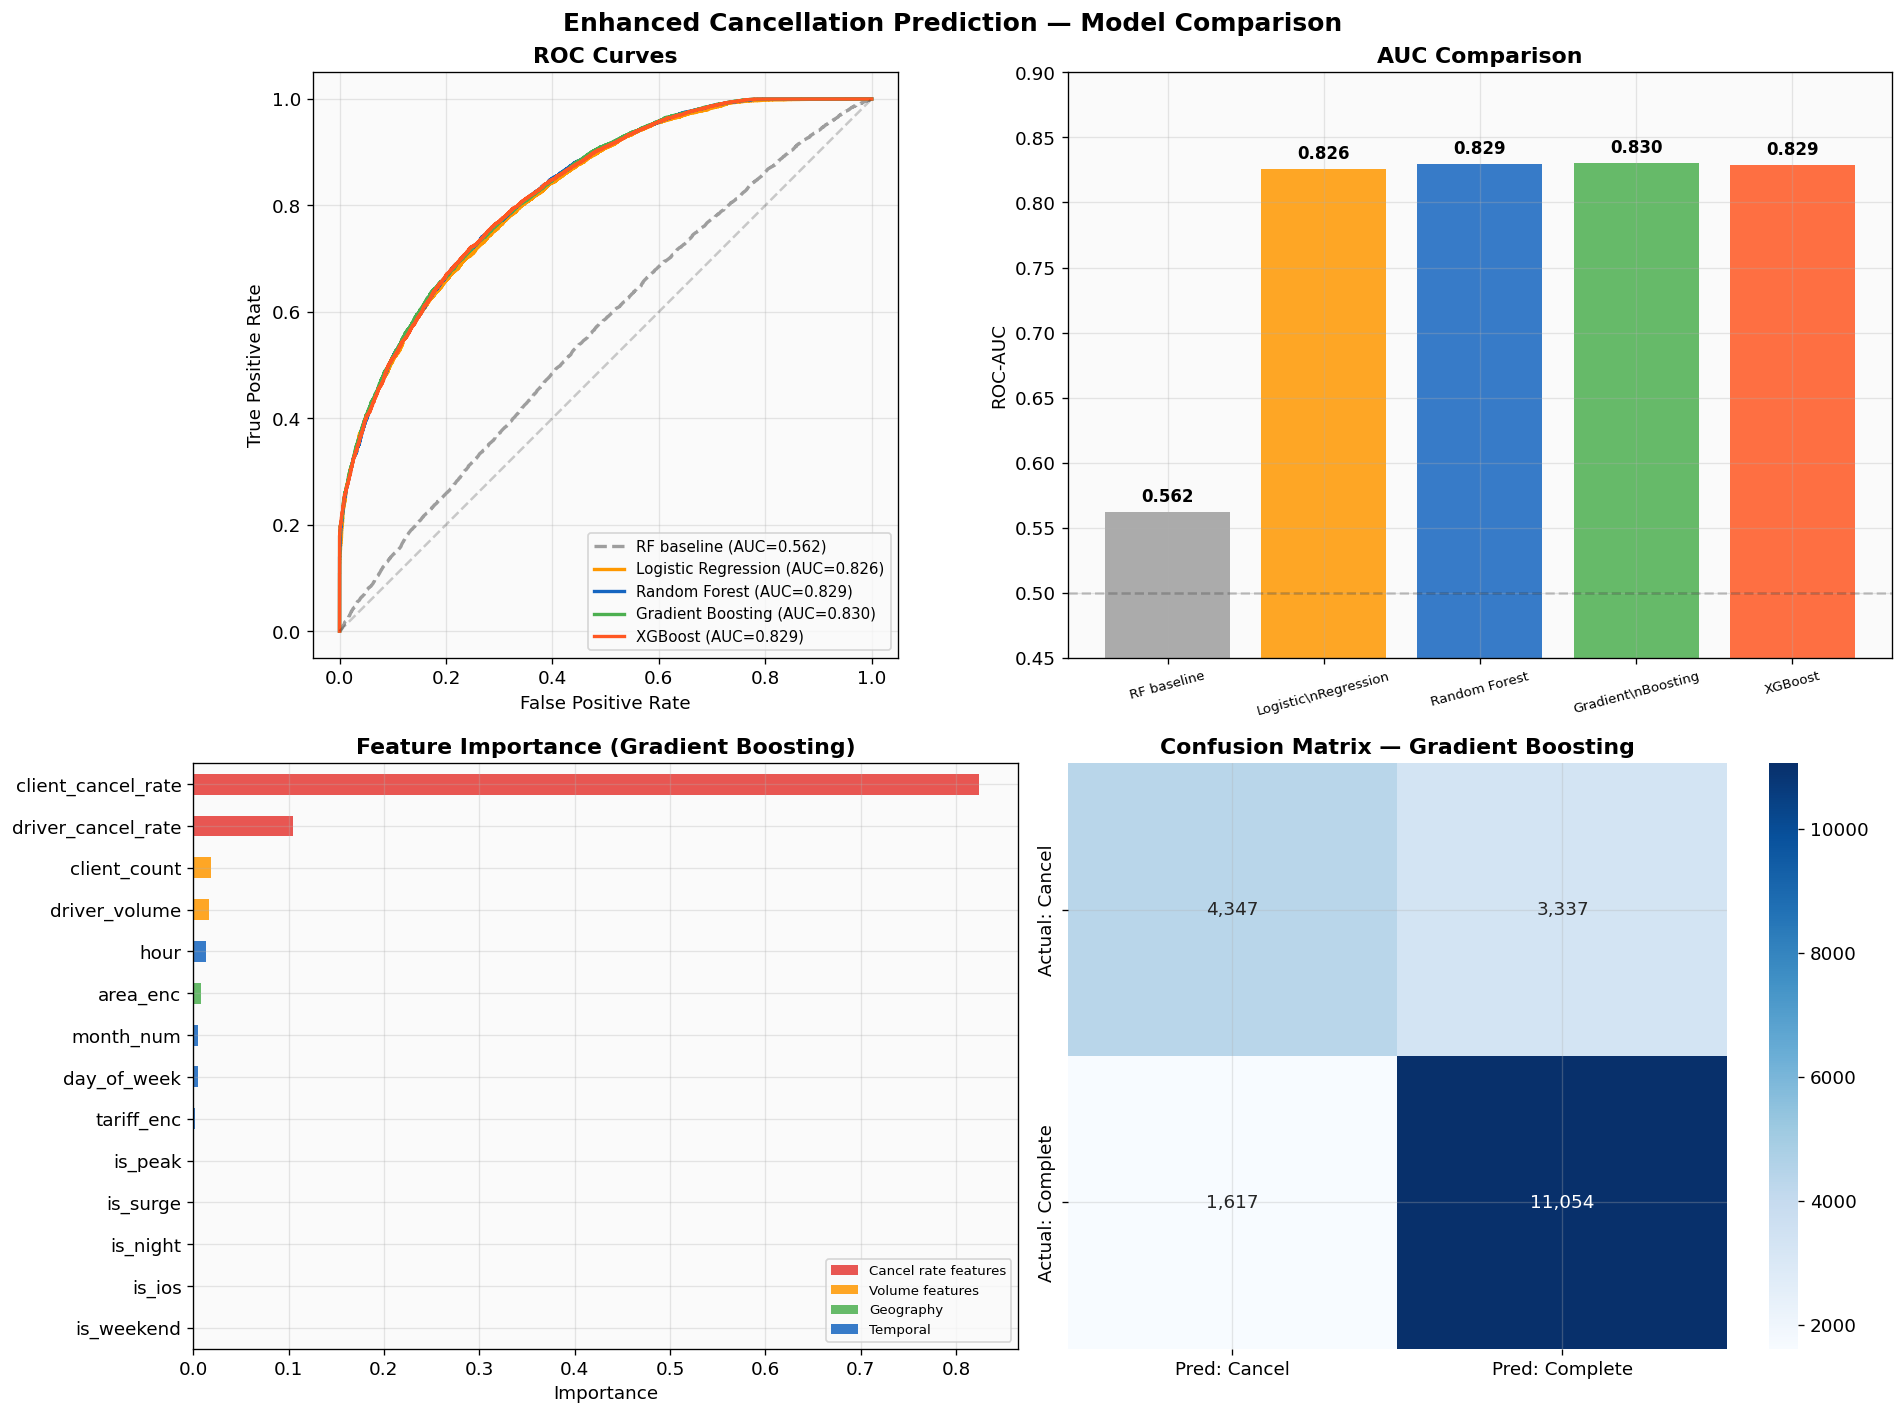

In [ ]:
# Model comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Enhanced Cancellation Prediction - Model Comparison', fontsize=15, fontweight='bold')

best = results[best_name]

# ROC curves
ax = axes[0, 0]
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_basic)
ax.plot(fpr_b, tpr_b, color=C['gray'], lw=2, ls='--', label=f'RF baseline (AUC={auc_basic:.3f})')
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    color = {'Logistic Regression':C['warning'],'Random Forest':C['primary'],
             'Gradient Boosting':C['success'],'XGBoost':C['secondary']}[name]
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={r["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.2)
ax.set_title('ROC Curves', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9); ax.set_aspect('equal')

# AUC comparison
ax = axes[0, 1]
names = ['RF baseline'] + list(results.keys())
aucs = [auc_basic] + [r['auc'] for r in results.values()]
colors_bar = [C['gray'], C['warning'], C['primary'], C['success'], C['secondary']]
bars = ax.bar(range(len(names)), aucs, color=colors_bar, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(' ',r'\n') if len(n)>15 else n for n in names], fontsize=8, rotation=15)
ax.set_title('AUC Comparison', fontweight='bold'); ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 0.9)
ax.axhline(0.5, color='k', ls='--', alpha=0.2)
for b, a in zip(bars, aucs):
    ax.text(b.get_x()+b.get_width()/2, a+0.008, f'{a:.3f}', ha='center', fontweight='bold', fontsize=10)

# Feature importance
ax = axes[1, 0]
imp = pd.Series(best['model'].feature_importances_, index=features_enhanced).sort_values()
colors_imp = [C['danger'] if 'cancel_rate' in f else C['warning'] if f in ['driver_volume','client_count']
              else C['success'] if f == 'area_enc' else C['primary'] for f in imp.index]
imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.85)
ax.set_title(f'Feature Importance ({best_name})', fontweight='bold')
ax.set_xlabel('Importance')
ax.legend([plt.Rectangle((0,0),1,1,fc=c,alpha=0.85) for c in [C['danger'],C['warning'],C['success'],C['primary']]],
          ['Cancel rate features','Volume features','Geography','Temporal'], fontsize=8, loc='lower right')

# Confusion matrix
ax = axes[1, 1]
y_pred = (best['y_prob'] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred: Cancel','Pred: Complete'],
            yticklabels=['Actual: Cancel','Actual: Complete'])
ax.set_title(f'Confusion Matrix - {best_name}', fontweight='bold')

plt.tight_layout(); plt.show()


### Model Comparison Findings

The enhanced behavioral features lift AUC from about 0.56 to about 0.83. This is the main result of the notebook: cancellation is much easier to predict when driver and client history are included.

The model family matters less than the feature design. Logistic Regression, Random Forest, Gradient Boosting, and XGBoost all perform in a similar range after behavioral features are added. Gradient Boosting is a practical choice because it performs well and is easy to interpret through feature importance.

The strongest signal is previous cancellation behavior. This should be interpreted carefully. It can reflect repeated off-platform behavior, weak supply areas, repeated client targeting, or other operational patterns. It is useful for monitoring, but it should not be treated as proof of misconduct without manual review.

## 3. Driver Risk Scoring

The model results are translated into a simpler driver-risk framework. This makes the analysis easier to use in operations because managers can monitor risk categories instead of inspecting individual model probabilities for every order.

In [ ]:
# Driver risk profiles
# Use anonymized labels and relative impact.
driver_risk = driver_stats.copy()
driver_risk = driver_risk[driver_risk['driver_total_orders'] >= 20]

driver_risk['risk_score'] = driver_risk['driver_cancel_rate']
driver_risk['risk_category'] = pd.cut(
    driver_risk['risk_score'],
    bins=[0, 0.2, 0.35, 0.5, 1.0],
    labels=['Low (<20%)', 'Medium (20-35%)', 'High (35-50%)', 'Critical (>50%)']
)

driver_risk['cancel_burden'] = driver_risk['driver_cancel_rate'] * driver_risk['driver_total_orders']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Driver Risk Scoring - Public View', fontsize=15, fontweight='bold')

risk_colors = [C['success'], C['warning'], C['secondary'], C['danger']]

ax = axes[0, 0]
rc = driver_risk['risk_category'].value_counts().sort_index()
bars = ax.bar(range(len(rc)), rc.values, color=risk_colors, alpha=0.85)
ax.set_xticks(range(len(rc)))
ax.set_xticklabels(rc.index, fontsize=9)
ax.set_title('Drivers by Risk Category', fontweight='bold')
ax.set_ylabel('Number of Drivers')
for b, v in zip(bars, rc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha='center', fontweight='bold')

ax = axes[0, 1]
sc = ax.scatter(
    driver_risk['driver_volume'], driver_risk['driver_cancel_rate'] * 100,
    c=driver_risk['risk_score'], cmap='RdYlGn_r', alpha=0.6, s=30,
    edgecolors='white', linewidth=0.5
)
ax.axhline(35, color='red', ls='--', alpha=0.5, label='High risk threshold')
ax.axhline(20, color='orange', ls='--', alpha=0.5, label='Medium risk threshold')
ax.set_title('Cancel Rate vs Order Volume', fontweight='bold')
ax.set_xlabel('Total Orders')
ax.set_ylabel('Cancel Rate, %')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='Risk Score')

ax = axes[1, 0]
risk_impact = driver_risk.groupby('risk_category', observed=True).agg(
    drivers=('driver_total_orders', 'count'),
    cancel_burden=('cancel_burden', 'sum')
)
risk_impact['burden_share'] = risk_impact['cancel_burden'] / risk_impact['cancel_burden'].sum() * 100
bars = ax.bar(range(len(risk_impact)), risk_impact['burden_share'], color=risk_colors, alpha=0.85)
ax.set_xticks(range(len(risk_impact)))
ax.set_xticklabels(risk_impact.index, fontsize=9)
ax.set_title('Relative Cancellation Burden by Category', fontweight='bold')
ax.set_ylabel('Share of cancellation burden, %')
for b, v in zip(bars, risk_impact['burden_share']):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

ax = axes[1, 1]
top20 = driver_risk.nlargest(20, 'risk_score').copy()
anon_labels = [f'Driver {i:02d}' for i in range(1, len(top20) + 1)]
ax.barh(range(len(top20)), top20['risk_score'] * 100, color=C['danger'], alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(anon_labels, fontsize=8)
ax.axvline(35, color='red', ls='--', alpha=0.5)
ax.set_title('Highest-Risk Drivers (anonymized)', fontweight='bold')
ax.set_xlabel('Cancel Rate, %')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print('DRIVER RISK SUMMARY')
for cat in rc.index:
    n = rc[cat]
    burden = risk_impact.loc[cat, 'burden_share']
    print(f'{cat}: {n} drivers, {burden:.1f}% of relative cancellation burden')
print(f'Total drivers analyzed: {len(driver_risk)}')
print('Driver names and exact monetary values are omitted.')


DRIVER RISK SUMMARY
Low risk (<20%): 13 drivers.
Medium risk (20-35%): 176 drivers.
High risk (35-50%): 178 drivers.
Critical risk (>50%): 106 drivers.
Total drivers analyzed: 473.
Driver names, exact monetary values, and monetary-impact graphics are omitted.


### Risk Scoring Findings

Drivers are grouped by their historical cancellation rate. Low-risk drivers can be prioritized and rewarded. Medium-risk drivers need monitoring and soft feedback. High-risk and critical profiles require stronger review, especially when cancellation behavior is repeated over many assigned orders.

The main value of this section is not punishment. It is governance. DodoGo needs a transparent way to identify unusual cancellation patterns, investigate them, and combine policy controls with positive incentives for reliable drivers.

A practical rollout would start with weekly monitoring, call masking for high-risk cases, and clear warnings before stronger action. The thresholds are simple enough to explain to the operations team and to drivers.

## 4. Real-Time Prediction

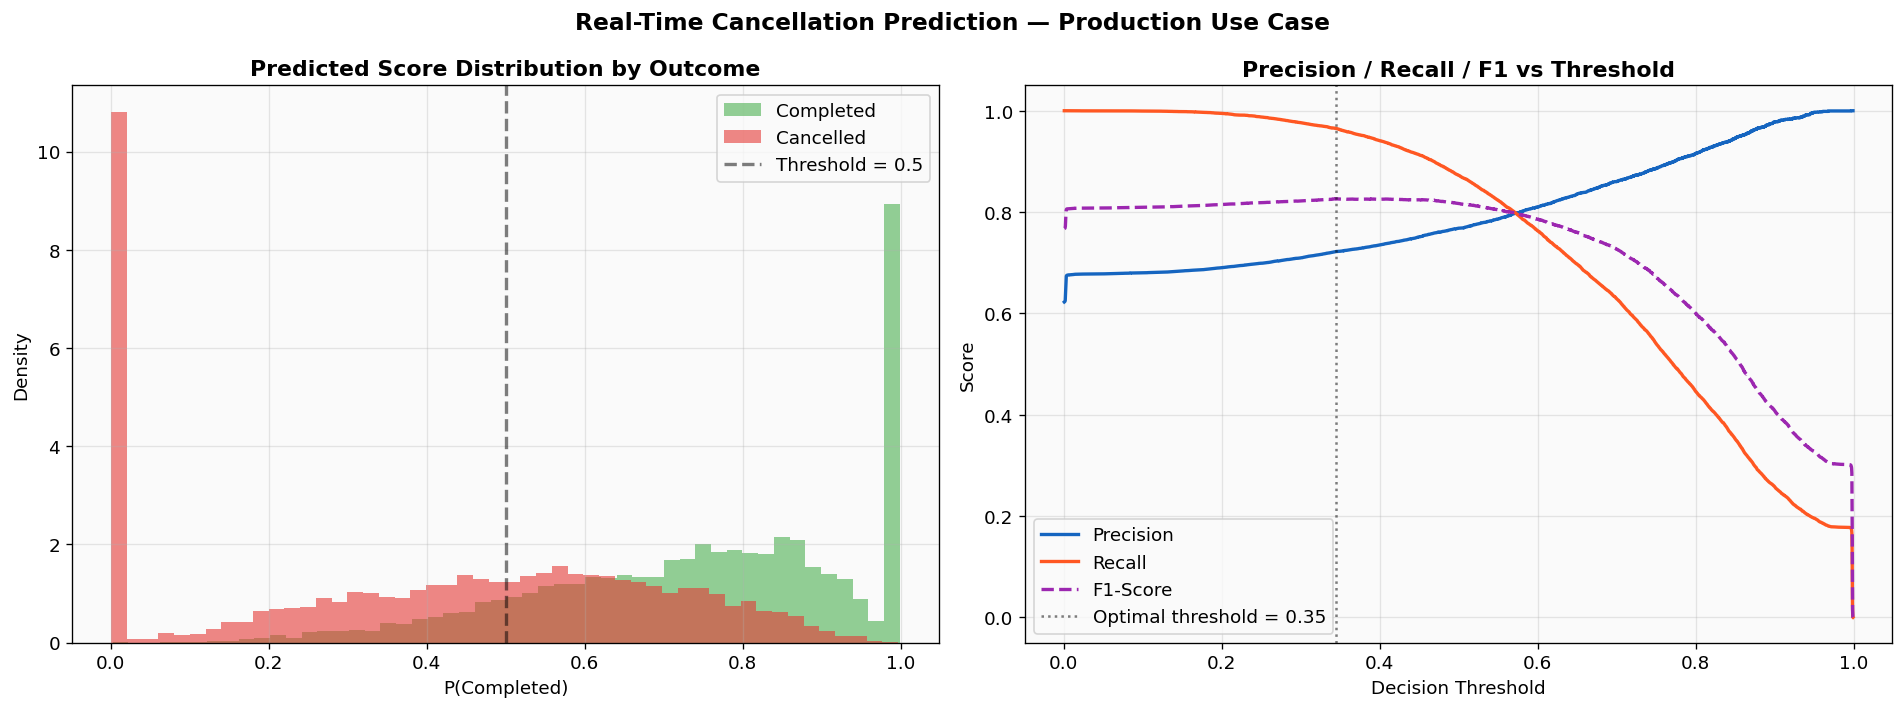

Optimal threshold (max F1): 0.345
At this threshold:
  Precision: 0.722
  Recall:    0.965
  F1-Score:  0.826


In [ ]:
# Production-style scoring example
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Real-Time Cancellation Prediction - Production Use Case', fontsize=14, fontweight='bold')

best_prob = results[best_name]['y_prob']

# Score distribution
ax = axes[0]
ax.hist(best_prob[y_test==1], bins=50, alpha=0.6, color=C['success'], label='Completed', density=True)
ax.hist(best_prob[y_test==0], bins=50, alpha=0.6, color=C['danger'], label='Cancelled', density=True)
ax.axvline(0.5, color='k', ls='--', lw=2, alpha=0.5, label='Threshold = 0.5')
ax.set_title('Predicted Score Distribution by Outcome', fontweight='bold')
ax.set_xlabel('P(Completed)'); ax.set_ylabel('Density'); ax.legend()

# Precision and recall by threshold
ax = axes[1]
prec, rec, thresh = precision_recall_curve(y_test, best_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-8)
best_thresh_idx = np.argmax(f1)
ax.plot(thresh, prec[:-1], color=C['primary'], lw=2, label='Precision')
ax.plot(thresh, rec[:-1], color=C['secondary'], lw=2, label='Recall')
ax.plot(thresh, f1[:-1], color=C['purple'], lw=2, ls='--', label='F1-Score')
ax.axvline(thresh[best_thresh_idx], color='k', ls=':', alpha=0.5,
           label=f'Optimal threshold = {thresh[best_thresh_idx]:.2f}')
ax.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Optimal threshold (max F1): {thresh[best_thresh_idx]:.3f}")
print(f"At this threshold:")
print(f"  Precision: {prec[best_thresh_idx]:.3f}")
print(f"  Recall:    {rec[best_thresh_idx]:.3f}")
print(f"  F1-Score:  {f1[best_thresh_idx]:.3f}")


### Production Use Case

A real-time version of the model would score a matched order using driver history, client history, pickup area, time, and tariff context. Low-risk orders can follow the normal flow. Medium-risk orders can receive reassurance messages. High-risk orders can trigger call masking, policy reminders, or monitoring.

The threshold should be chosen by business cost, not only by F1 score. A false positive creates a small operational cost, while a false negative can mean a missed opportunity to prevent cancellation or off-platform movement.

This use case connects the model to product design. It shows how prediction can support a practical intervention rather than remain only an offline accuracy metric.

## 5. Summary

| Metric | Baseline | Enhanced | Leakage-safe extension |
|---|---|---|---|
| Feature set | Timing and order context | Driver, client, and area history | Strictly pre-order behavioral features |
| Single-split AUC | 0.562 | About 0.830 | About 0.831 to 0.861 depending on setup |
| Cross-validation | Limited signal | About 0.833 | Stable improvement in manual validation |
| Main signal | Hour and month | Prior cancellation behavior | Prior cancellation and completion behavior |

Summary points:

1. Timing features alone are not enough for cancellation prediction.
2. Driver and client behavioral history explain most of the improvement.
3. Leakage-safe features preserve the same business story and improve methodological quality.
4. The most useful output is the driver-risk framework, because it can be connected directly to monitoring, call masking, and operational policy.